# Student Performance Analysis Project

## Imports libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Dataset Loading 

In [48]:
df = pd.read_csv("student_performance.csv")
df.head()

,student_id,name,gender,age,class,teacher_id,subject,test1_score,test2_score,final_exam_score
0,1,Carson Rivera,Female,14,9th,105,Math,23.5,40.5,50.5
1,2,Ashley Walters,Male,15,10th,107,Computer,77.7,80.6,82.3
2,3,Linda Robinson,Male,15,10th,103,English,75.0,73.4,64.5
3,4,Brandon James,Female,17,11th,117,Computer,46.7,53.1,51.2
4,5,Helen Grant,Female,16,10th,112,Science,38.0,57.3,47.6


In [4]:
df.columns

Index(['student_id', 'name', 'gender', 'age', 'class', 'teacher_id', 'subject',
       'test1_score', 'test2_score', 'final_exam_score'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        1000 non-null   int64  
 1   name              1000 non-null   str    
 2   gender            1000 non-null   str    
 3   age               1000 non-null   int64  
 4   class             1000 non-null   str    
 5   teacher_id        1000 non-null   int64  
 6   subject           1000 non-null   str    
 7   test1_score       1000 non-null   float64
 8   test2_score       1000 non-null   float64
 9   final_exam_score  1000 non-null   float64
dtypes: float64(3), int64(3), str(4)
memory usage: 105.4 KB


# 3.Data Cleaning and Processing Steps

## 3.1 Check Missing Values & Duplicates

In [6]:
df.isnull().sum()

student_id          0
name                0
gender              0
age                 0
class               0
teacher_id          0
subject             0
test1_score         0
test2_score         0
final_exam_score    0
dtype: int64

In [7]:
df.duplicated().sum()

0

### 3.2 Summary Statistics & Unique Categorical Values

In [8]:
df[["age" ,"test1_score" , "test2_score" , "final_exam_score" ]].describe()

,age,test1_score,test2_score,final_exam_score
count,1000.000000,1000.000000,1000.00000,1000.000000
mean,15.885000,63.943300,66.12620,68.411400
std,1.223631,14.761535,14.94783,15.496406
min,14.000000,17.100000,24.40000,25.000000
25%,15.000000,53.800000,56.37500,57.400000
50%,16.000000,64.000000,65.70000,68.000000
75%,17.000000,73.900000,76.92500,79.325000
max,18.000000,100.000000,100.00000,100.000000


In [9]:
df["gender"].unique()

<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

In [10]:
df["subject"].unique()

<ArrowStringArray>
['Math', 'Computer', 'English', 'Science', 'Art', 'History']
Length: 6, dtype: str

In [11]:
df["class"].unique()

<ArrowStringArray>
['9th', '10th', '11th', '12th']
Length: 4, dtype: str

In [12]:
df["gender"].value_counts()

gender
Male      529
Female    471
Name: count, dtype: int64

In [13]:
df["subject"].value_counts()

subject
Math        225
Computer    193
English     193
Science     187
History     153
Art          49
Name: count, dtype: int64

In [14]:
df["class"].value_counts()

class
9th     283
12th    251
11th    247
10th    219
Name: count, dtype: int64

# Exporatory Data Analysis (EDA)

### 4.1 Overall Average Scores

In [15]:
df["test1_score"].mean()

63.9433

In [16]:
df["test2_score"].mean()

66.12620000000001

In [17]:
df["final_exam_score"].mean()

68.4114

### 4.2 Subject-Wise Final Exam Performance

In [18]:
subject_avg = df.groupby("subject")["final_exam_score"].mean()

In [19]:
subject_avg

subject
Art         70.587755
Computer    70.644041
English     70.496373
History     67.997386
Math        65.983556
Science     66.644920
Name: final_exam_score, dtype: float64

### 4.3 Subject-Wise Final Exam Score Visualization

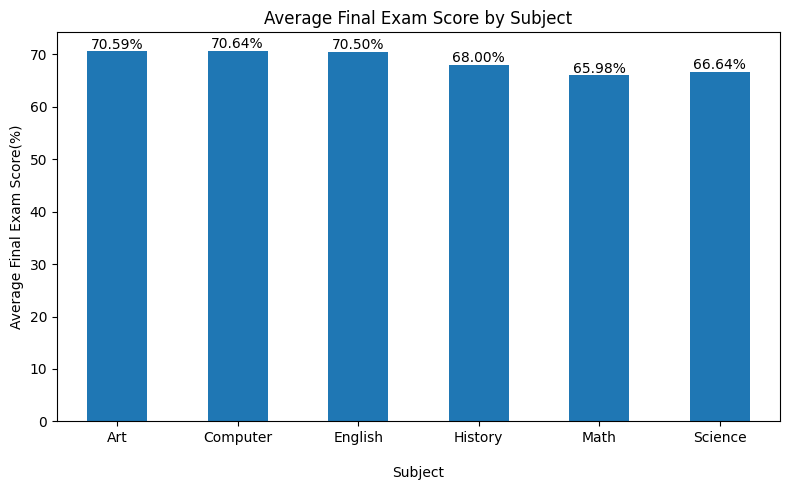

In [20]:
ax = subject_avg.plot(kind = "bar", figsize=(8,5))

plt.title("Average Final Exam Score by Subject")
plt.xlabel("Subject" , labelpad = 15)
plt.ylabel("Average Final Exam Score(%)")

for i, value in enumerate(subject_avg):
    ax.text(i, value + 0.5 , f"{value:.2f}%", ha="center")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.4.Then Visuallize Final Result gender Wise in Bar Graph

In [21]:
gender_avg = df.groupby("gender")["final_exam_score"].mean()

In [22]:
gender_avg

gender
Female    68.823567
Male      68.044423
Name: final_exam_score, dtype: float64

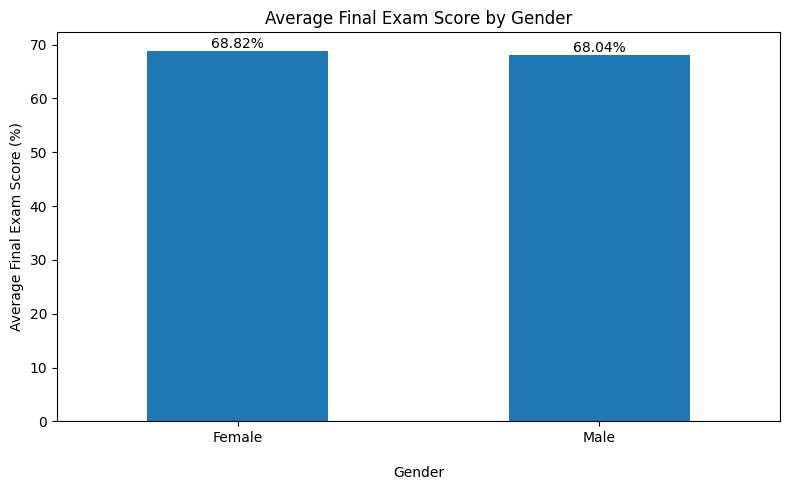

In [23]:
ax = gender_avg.plot(kind="bar", figsize=(8, 5))

plt.title("Average Final Exam Score by Gender")
plt.xlabel("Gender", labelpad=15)
plt.ylabel("Average Final Exam Score (%)")

for i, value in enumerate(gender_avg):
    ax.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.5.Then Visuallize Final Result Class Wise in Bar Graph

In [24]:
class_avg = df.groupby("class")["final_exam_score"].mean()

In [25]:
class_avg

class
10th    67.924201
11th    69.946154
12th    68.543426
9th     67.331802
Name: final_exam_score, dtype: float64

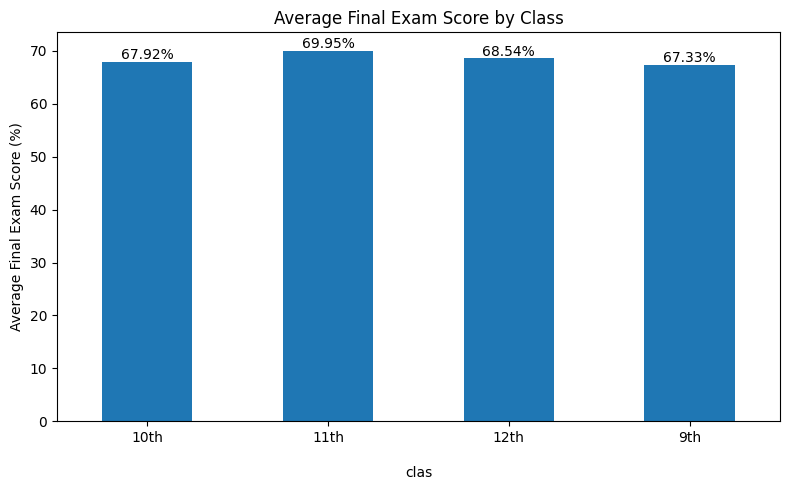

In [26]:
ax = class_avg.plot(kind = "bar" , figsize = (8,5))

plt.title("Average Final Exam Score by Class")
plt.xlabel("clas" , labelpad = 15)
plt.ylabel("Average Final Exam Score (%)")

for i, value in enumerate(class_avg):
    ax.text(i, value + 0.5 , f"{value:.2f}%" , ha="center")

plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

### 4.6 Then Visuallize Final Result Test Wise in Scatter Graph

### 4.6.1 Then Visuallize Final Result Test1 in Scatter Graph

In [27]:
df["test1_score"].corr(df["final_exam_score"])

0.7917583013990549

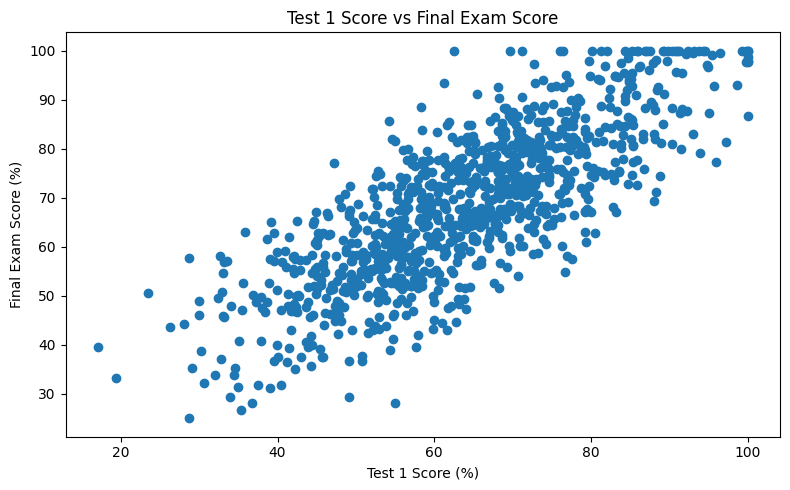

In [28]:
plt.figure(figsize = (8,5))

plt.scatter(df["test1_score"], df["final_exam_score"])

plt.title("Test 1 Score vs Final Exam Score")
plt.xlabel("Test 1 Score (%)")
plt.ylabel("Final Exam Score (%)")

plt.tight_layout()
plt.show()

## 2.Then Visuallize Final Result Test1 in Bar Graph

In [29]:
df["test2_score"].corr(df["final_exam_score"])

0.7828225202427535

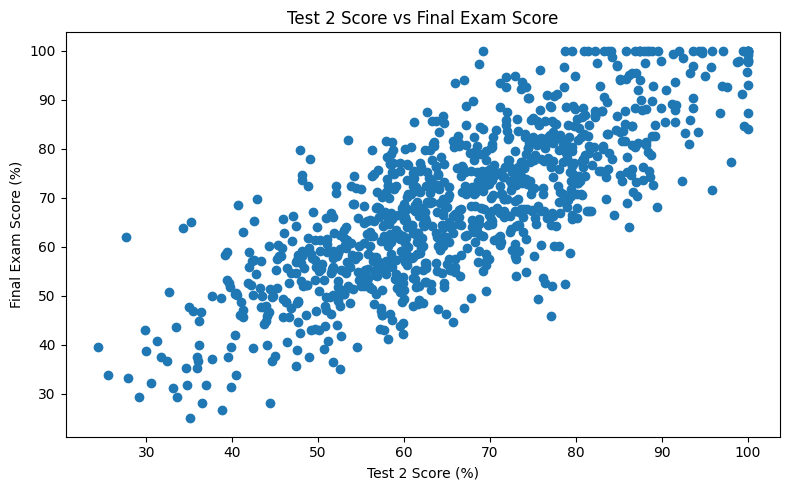

In [30]:
plt.figure(figsize = (8,5))

plt.scatter(df["test2_score"], df["final_exam_score"])

plt.title("Test 2 Score vs Final Exam Score")
plt.xlabel("Test 2 Score (%)")
plt.ylabel("Final Exam Score (%)")

plt.tight_layout()
plt.show()

## Correlation Analysis

In [31]:
correlation = df[["age" , "test1_score" , "test2_score" , "final_exam_score"]].corr()

In [32]:
correlation

,age,test1_score,test2_score,final_exam_score
age,1.000000,0.009315,0.031584,0.034388
test1_score,0.009315,1.000000,0.830717,0.791758
test2_score,0.031584,0.830717,1.000000,0.782823
final_exam_score,0.034388,0.791758,0.782823,1.000000


## Correlation Analysis Heatmap

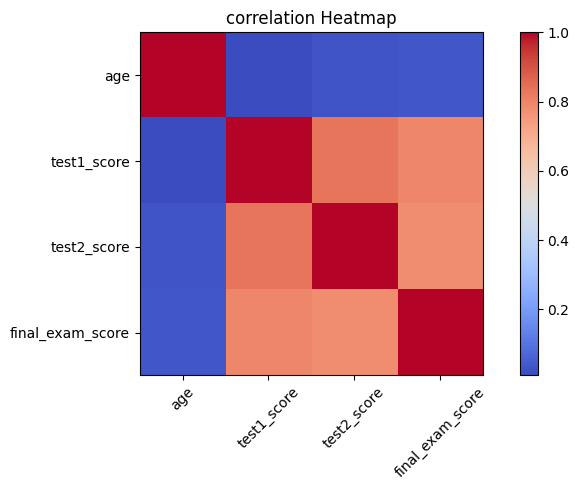

In [33]:
plt.figure(figsize=(8,5))

plt.imshow(correlation , cmap = "coolwarm")

plt.colorbar()

plt.xticks(range(len(correlation.columns)),correlation.columns, rotation = 45)
plt.yticks(range(len(correlation.columns)),correlation.columns)

plt.title("correlation Heatmap")

plt.tight_layout()
plt.show()

# Pass/Fail Analysis

In [34]:
df["result"] = np.where(
    df["final_exam_score"] >= 50,
    "pass", "Fail"
)

In [35]:
df[["final_exam_score", "result"]].head(10)

,final_exam_score,result
0,50.5,pass
1,82.3,pass
2,64.5,pass
3,51.2,pass
4,47.6,Fail
5,83.1,pass
6,59.1,pass
7,76.5,pass
8,77.3,pass
9,60.8,pass


In [36]:
df["result"].value_counts()

result
pass    884
Fail    116
Name: count, dtype: int64

In [37]:
result_percentage = df["result"].value_counts(normalize = True) * 100

In [38]:
result_percentage

result
pass    88.4
Fail    11.6
Name: proportion, dtype: float64

## Pass/Fail visualization in Bar Graph

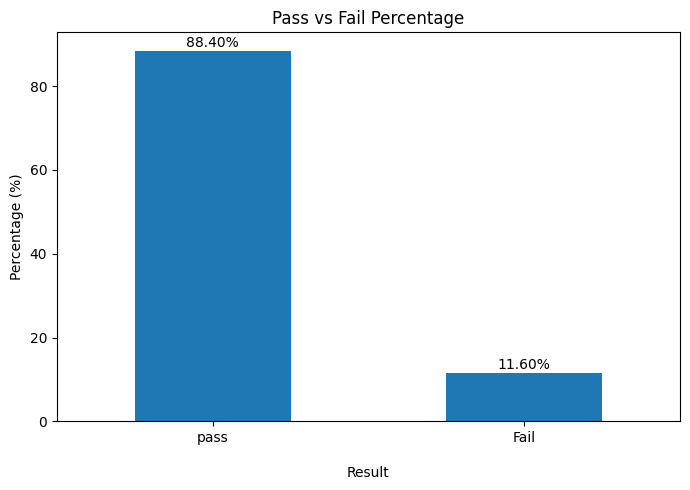

In [39]:
ax = result_percentage.plot(kind = "bar" , figsize = (7,5))

plt.title("Pass vs Fail Percentage")
plt.xlabel("Result" , labelpad = 15)
plt.ylabel("Percentage (%)")

for i,value in enumerate(result_percentage):
    ax.text(i, value+1 , f"{value:.2f}%" , ha = "center")

plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

## Score Distribution

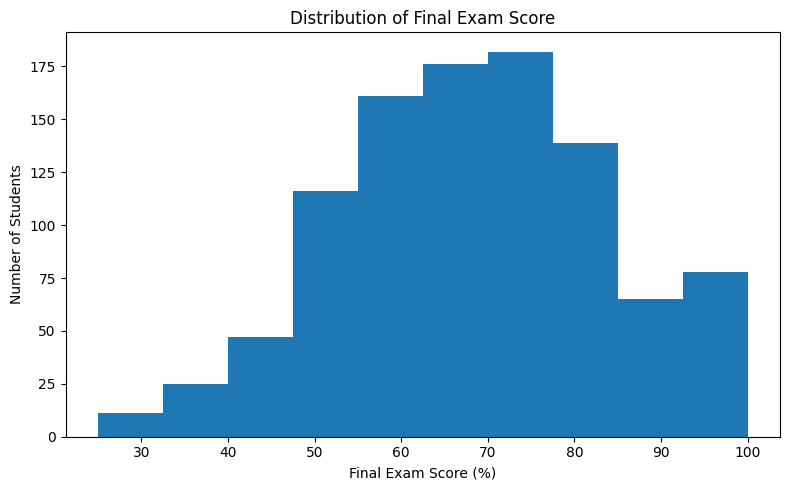

In [40]:
plt.figure(figsize = (8,5))

plt.hist(df["final_exam_score"], bins = 10)

plt.title("Distribution of Final Exam Score")
plt.xlabel("Final Exam Score (%)")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

## Outlier Analysis

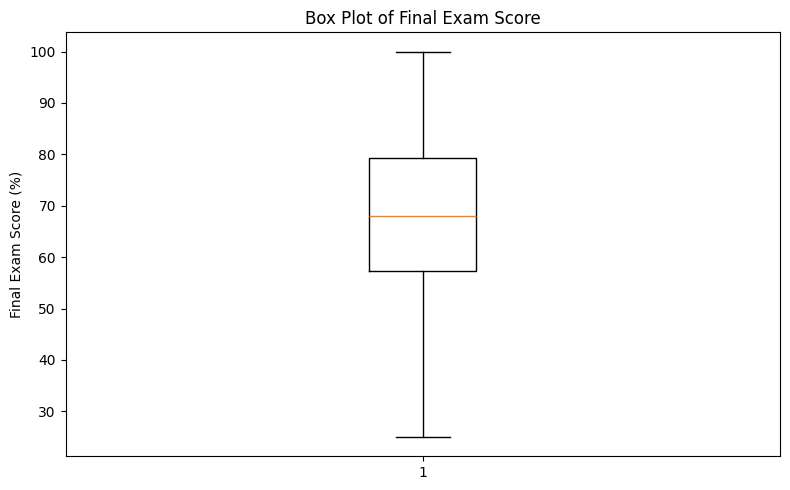

In [41]:
plt.figure(figsize = (8,5))

plt.boxplot(df["final_exam_score"])

plt.title("Box Plot of Final Exam Score")
plt.ylabel("Final Exam Score (%)")

plt.tight_layout()
plt.show()

## Visualization: Test1 vs Test2

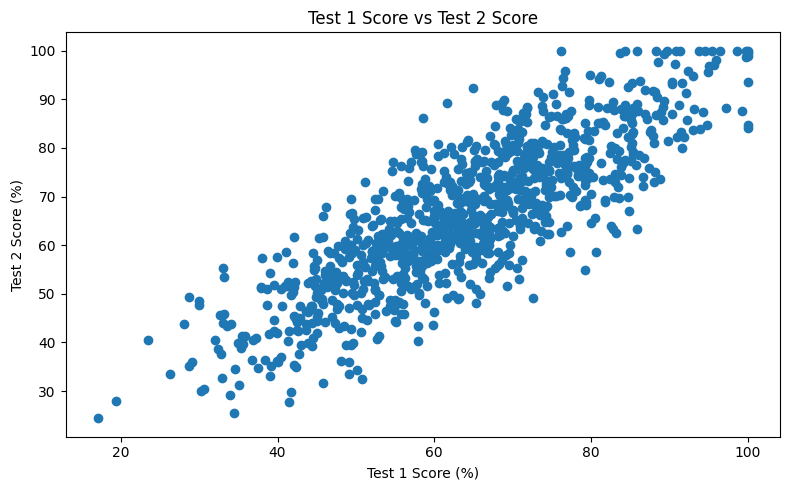

In [43]:
plt.figure(figsize = (8,5))

plt.scatter(df["test1_score"],df["test2_score"])

plt.title("Test 1 Score vs Test 2 Score")
plt.xlabel("Test 1 Score (%)")
plt.ylabel("Test 2 Score (%)")

plt.tight_layout()
plt.show()

# Final Analysis

* Overall Average Final Score
* Pass/Fail Percentage
* Subject-Wise Performance
* Gender-Wise Performance
* Class-Wise Performance
* Correlation Matrix

In [47]:
print("Overall Average Final Exam Score. " , df["final_exam_score"].mean())

print("\nPass/Fail Percentage")
print(df["result"].value_counts(normalize = True) * 100)

print("\nSubject-wise Average")
print(df.groupby("subject")["final_exam_score"].mean())

print("\nGender-wise Average")
print(df.groupby("gender")["final_exam_score"].mean())

print("\nClass-wise Average")
print(df.groupby("class")["final_exam_score"].mean())

print("\nCorrelations")
print(df[["age" , "test1_score" , "test2_score" , "final_exam_score"]].corr())

Overall Average Final Exam Score.  68.4114

Pass/Fail Percentage
result
pass    88.4
Fail    11.6
Name: proportion, dtype: float64

Subject-wise Average
subject
Art         70.587755
Computer    70.644041
English     70.496373
History     67.997386
Math        65.983556
Science     66.644920
Name: final_exam_score, dtype: float64

Gender-wise Average
gender
Female    68.823567
Male      68.044423
Name: final_exam_score, dtype: float64

Class-wise Average
class
10th    67.924201
11th    69.946154
12th    68.543426
9th     67.331802
Name: final_exam_score, dtype: float64

Correlations
                       age  test1_score  test2_score  final_exam_score
age               1.000000     0.009315     0.031584          0.034388
test1_score       0.009315     1.000000     0.830717          0.791758
test2_score       0.031584     0.830717     1.000000          0.782823
final_exam_score  0.034388     0.791758     0.782823          1.000000
